In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
df = pd.read_csv("/content/Movie.csv")

In [20]:
df.head()

,userId,movie,rating
0,3,Toy Story (1995),4.0
1,6,Toy Story (1995),5.0
2,8,Toy Story (1995),4.0
3,10,Toy Story (1995),4.0
4,11,Toy Story (1995),4.5


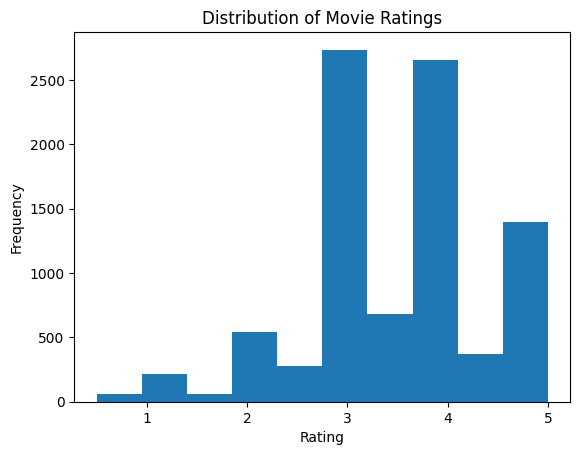

In [21]:
plt.hist(df["rating"])
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Movie Ratings")
plt.show()

In [22]:
user_item_matrix = df.pivot_table( index = "userId" ,columns="movie", values="rating")
user_item_matrix = user_item_matrix.fillna(0)

In [23]:
user_item_matrix

movie,Father of the Bride Part II (1995),GoldenEye (1995),Grumpier Old Men (1995),Heat (1995),Jumanji (1995),Sabrina (1995),Sudden Death (1995),Tom and Huck (1995),Toy Story (1995),Waiting to Exhale (1995)
userId,,,,,,,,,,
1,0.0,0.0,0.0,0.0,3.5,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
4,0.0,4.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
7115,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7116,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
7117,0.0,3.0,4.0,5.0,0.0,3.0,1.0,0.0,4.0,0.0


In [24]:
user_item_matrix.T

userId,1,2,3,4,5,6,7,8,10,11,...,7105,7107,7108,7110,7113,7115,7116,7117,7119,7120
movie,,,,,,,,,,,,,,,,,,,,,
Father of the Bride Part II (1995),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,3.5,0.0,0.0,0.0
GoldenEye (1995),0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,2.5,...,2.0,0.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,0.0
Grumpier Old Men (1995),0.0,4.0,0.0,0.0,0.0,3.0,3.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0
Heat (1995),0.0,0.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,5.0,0.0,0.0
Jumanji (1995),3.5,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,4.0
Sabrina (1995),0.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,4.0
Sudden Death (1995),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Tom and Huck (1995),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Toy Story (1995),0.0,0.0,4.0,0.0,0.0,5.0,0.0,4.0,4.0,4.5,...,0.0,4.0,0.0,4.0,0.0,0.0,4.0,4.0,5.0,4.5


In [25]:
from sklearn.metrics.pairwise import cosine_similarity
iterm_similarities = cosine_similarity(user_item_matrix.T)

In [26]:
iterm_similarities

array([[1.        , 0.21599275, 0.45566216, 0.24736744, 0.27980393,
        0.39574604, 0.22645759, 0.16293622, 0.30863759, 0.16378738],
       [0.21599275, 1.        , 0.21819777, 0.39773907, 0.40226034,
        0.22145469, 0.1552551 , 0.11972423, 0.38348625, 0.12844824],
       [0.45566216, 0.21819777, 1.        , 0.2901502 , 0.24471005,
        0.39017783, 0.25538652, 0.14395914, 0.31691062, 0.1564475 ],
       [0.24736744, 0.39773907, 0.2901502 , 1.        , 0.2800876 ,
        0.26207226, 0.25562862, 0.06285821, 0.40011642, 0.12402064],
       [0.27980393, 0.40226034, 0.24471005, 0.2800876 , 1.        ,
        0.24667163, 0.14328579, 0.19637377, 0.40998238, 0.14767896],
       [0.39574604, 0.22145469, 0.39017783, 0.26207226, 0.24667163,
        1.        , 0.20155614, 0.16464129, 0.31043392, 0.1894145 ],
       [0.22645759, 0.1552551 , 0.25538652, 0.25562862, 0.14328579,
        0.20155614, 1.        , 0.09721338, 0.16679265, 0.15179972],
       [0.16293622, 0.11972423, 0.1439591

In [27]:
item_similarities_df= pd.DataFrame(iterm_similarities, index = user_item_matrix.columns, columns = user_item_matrix.columns)

In [28]:
item_similarities_df

movie,Father of the Bride Part II (1995),GoldenEye (1995),Grumpier Old Men (1995),Heat (1995),Jumanji (1995),Sabrina (1995),Sudden Death (1995),Tom and Huck (1995),Toy Story (1995),Waiting to Exhale (1995)
movie,,,,,,,,,,
Father of the Bride Part II (1995),1.000000,0.215993,0.455662,0.247367,0.279804,0.395746,0.226458,0.162936,0.308638,0.163787
GoldenEye (1995),0.215993,1.000000,0.218198,0.397739,0.402260,0.221455,0.155255,0.119724,0.383486,0.128448
Grumpier Old Men (1995),0.455662,0.218198,1.000000,0.290150,0.244710,0.390178,0.255387,0.143959,0.316911,0.156447
Heat (1995),0.247367,0.397739,0.290150,1.000000,0.280088,0.262072,0.255629,0.062858,0.400116,0.124021
Jumanji (1995),0.279804,0.402260,0.244710,0.280088,1.000000,0.246672,0.143286,0.196374,0.409982,0.147679
Sabrina (1995),0.395746,0.221455,0.390178,0.262072,0.246672,1.000000,0.201556,0.164641,0.310434,0.189415
Sudden Death (1995),0.226458,0.155255,0.255387,0.255629,0.143286,0.201556,1.000000,0.097213,0.166793,0.151800
Tom and Huck (1995),0.162936,0.119724,0.143959,0.062858,0.196374,0.164641,0.097213,1.000000,0.095521,0.148723
Toy Story (1995),0.308638,0.383486,0.316911,0.400116,0.409982,0.310434,0.166793,0.095521,1.000000,0.138524


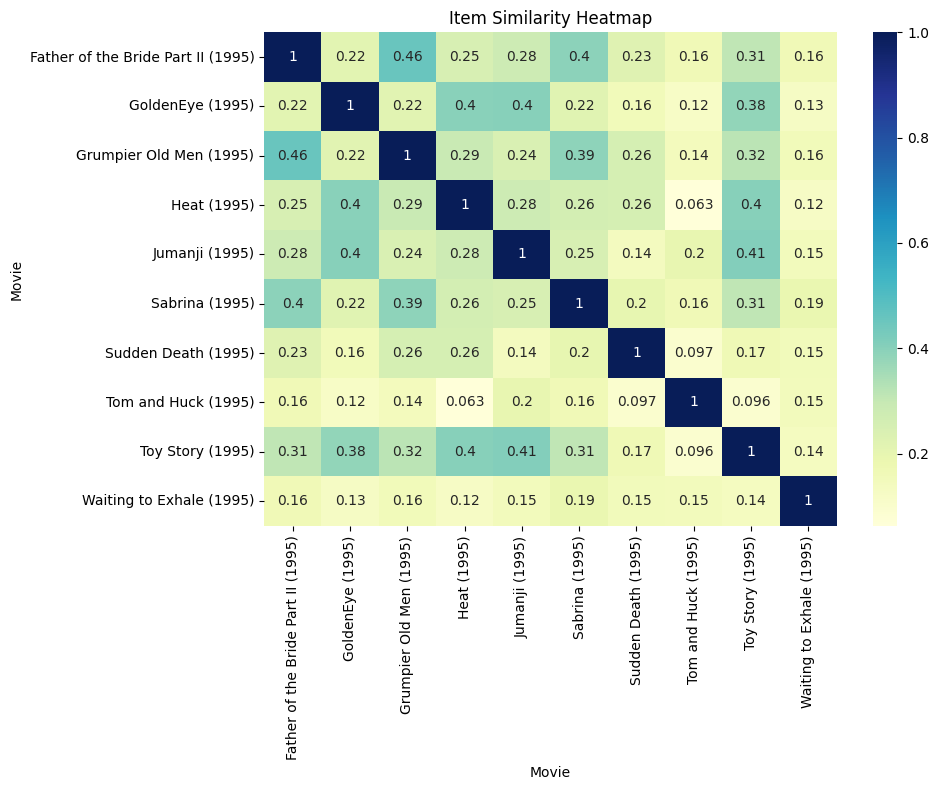

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(item_similarities_df, cmap='YlGnBu', annot=True)
plt.title('Item Similarity Heatmap')
plt.xlabel('Movie')
plt.ylabel('Movie')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
def find_similar_movies(movie_title,  num_recommendations=3):
   similar_movie = item_similarities_df[movie_title].sort_values(ascending=False)
   return similar_movie.iloc[1:num_recommendations+1]

In [32]:
find_similar_movies(movie_title = "Father of the Bride Part II (1995)")

,Father of the Bride Part II (1995)
movie,
Grumpier Old Men (1995),0.455662
Sabrina (1995),0.395746
Toy Story (1995),0.308638


In [33]:
def show_user_profiles(user_id):
  uder_ratings = user_item_matrix.loc[user_id]
  return uder_ratings[uder_ratings > 0].sort_values(ascending=False)

In [34]:
show_user_profiles(np.random.choice(user_item_matrix.index))

,516
movie,
Toy Story (1995),5.0
Grumpier Old Men (1995),4.0
Sudden Death (1995),1.0


In [41]:
def recommend_movies(user_id, num_recommendations = 5):

  user_rating = user_item_matrix.loc[user_id]

  rated_movies = user_rating[user_rating > 0 ]

  if rated_movies.empty:
     return f"User {user_id} has not rated any movies."

  unrated_movies = user_rating[user_rating == 0].index

  recommendations = {}
  for movie in unrated_movies:
       similar_movies = item_similarities_df.loc[movie , rated_movies.index]
       score = (similar_movies * rated_movies).mean()
       recommendations[movie] = score

  top_movies = pd.Series(recommendations).sort_values(ascending=False).head(num_recommendations)
  return top_movies

In [42]:
print(recommend_movies(1))

Toy Story (1995)                      1.434938
GoldenEye (1995)                      1.407911
Heat (1995)                           0.980307
Father of the Bride Part II (1995)    0.979314
Sabrina (1995)                        0.863351
dtype: float64
